# 03b_Contiguous_Peptide_Window_Diffusion_EnergeticHotspots.ipynb

## PEARL — contiguous peptide-window diffusion guided by FoldX energetic hotspots

This notebook replaces the previous graph-proxy version of `03b`.

Main change:

> The diffusion model is now guided by **FoldX alanine-scanning energetic hotspots**, not only by graph centrality.

Expected upstream notebook:

```text
02b_Interface_Hotspot_AlanineScanning_FoldX.ipynb
```

Expected inputs:

```text
outputs/energetic_hotspots.csv
outputs/interface_residues_with_foldx_ddg.csv
outputs/energetic_contiguous_windows_ranked.csv
outputs/interface_nodes.csv
```

Expected outputs:

```text
outputs/selected_energetic_seed_window.csv
outputs/selected_energetic_seed_metadata.csv
outputs/diffusion_contiguous_peptide_candidates.csv
outputs/diffusion_energetic_peptide_candidates.csv
```

Scientific interpretation:

- `is_energetic_hotspot` is the PEARL-compliant hotspot definition.
- It is based on FoldX alanine scanning and the criterion `ΔΔG > 1.5 kcal/mol`.
- Graph centrality is retained only as auxiliary information.


### Terminology note

In this notebook, the legacy terms `energetic_hotspot`,
`is_energetic_hotspot`, and related variable names refer to residues
classified by the original FoldX **BuildModel mutation-energy
sensitivity** criterion used in notebook 02b.

These labels are retained for code and output compatibility and should
not be interpreted as experimentally validated binding hotspots or as
direct estimates of binding ΔΔG.

The interaction-specific FoldX assessment is provided separately by
notebook 02c using `AnalyseComplex`. The A07 analysis derived from that
validation refines the 30-residue seed selection from the historical
D:21–50 window to **D:22–51**.

## 0. Setup

In [1]:
from pathlib import Path
import os
import math
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from Bio.PDB import PDBParser, is_aa
except ImportError as e:
    raise ImportError("Biopython is required. Install it with: pip install biopython") from e

SEED_RANDOM = 42
random.seed(SEED_RANDOM)
np.random.seed(SEED_RANDOM)
torch.manual_seed(SEED_RANDOM)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)
NL = chr(10)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

PDB_ID = "3NJP"
DOMAIN_CHAIN = "B"
PEPTIDE_CHAIN = "D"

DDG_HOTSPOT_THRESHOLD = 1.5

print("Output directory:", OUTPUT_DIR.resolve())


Device: mps
Output directory: /Users/robertobruzzese/Desktop/venv/outputs


## 1. Load FoldX energetic hotspot outputs

This notebook expects the output of notebook `02b`.

The key file is:

```text
outputs/energetic_hotspots.csv
```

If this file is empty, FoldX has not yet produced usable energetic hotspots. In that case, run FoldX or provide the manual CSV required by notebook `02b`, then rerun `02b`.


In [2]:
ENERGETIC_HOTSPOTS_PATH = OUTPUT_DIR / "energetic_hotspots.csv"
INTERFACE_DDG_PATH = OUTPUT_DIR / "interface_residues_with_foldx_ddg.csv"
ENERGETIC_WINDOWS_PATH = OUTPUT_DIR / "energetic_contiguous_windows_ranked.csv"
NODES_PATH = OUTPUT_DIR / "interface_nodes.csv"

print("energetic_hotspots exists:", ENERGETIC_HOTSPOTS_PATH.exists(), ENERGETIC_HOTSPOTS_PATH)
print("interface_residues_with_foldx_ddg exists:", INTERFACE_DDG_PATH.exists(), INTERFACE_DDG_PATH)
print("energetic windows exists:", ENERGETIC_WINDOWS_PATH.exists(), ENERGETIC_WINDOWS_PATH)
print("nodes exists:", NODES_PATH.exists(), NODES_PATH)

if not INTERFACE_DDG_PATH.exists():
    raise FileNotFoundError(
        "Missing outputs/interface_residues_with_foldx_ddg.csv. "
        "Run 02b_Interface_Hotspot_AlanineScanning_FoldX.ipynb first."
    )

interface_ddg = pd.read_csv(INTERFACE_DDG_PATH)
energetic_hotspots = pd.read_csv(ENERGETIC_HOTSPOTS_PATH) if ENERGETIC_HOTSPOTS_PATH.exists() else pd.DataFrame()
energetic_windows = pd.read_csv(ENERGETIC_WINDOWS_PATH) if ENERGETIC_WINDOWS_PATH.exists() else pd.DataFrame()
nodes = pd.read_csv(NODES_PATH) if NODES_PATH.exists() else pd.DataFrame()

print("interface_ddg shape:", interface_ddg.shape)
print("energetic_hotspots shape:", energetic_hotspots.shape)
print("energetic_windows shape:", energetic_windows.shape)

display(interface_ddg.head())
display(energetic_hotspots.head())
display(energetic_windows.head())


energetic_hotspots exists: True outputs/energetic_hotspots.csv
interface_residues_with_foldx_ddg exists: True outputs/interface_residues_with_foldx_ddg.csv
energetic windows exists: True outputs/energetic_contiguous_windows_ranked.csv
nodes exists: True outputs/interface_nodes.csv
interface_ddg shape: (74, 17)
energetic_hotspots shape: (15, 17)
energetic_windows shape: (194, 12)


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required,ddG_kcal_mol,source_file,raw_line,has_foldx_ddg,is_energetic_hotspot,is_graph_proxy_hotspot_like
0,B,384,GLN,B:GLN384,Q,4,4,0.219768,0.445791,QB384A;,True,NaN,NaN,NaN,False,False,True
1,B,18,GLY,B:GLY18,G,2,2,0.011622,0.095690,GB18A;,True,NaN,NaN,NaN,False,False,False
2,B,90,GLU,B:GLU90,E,1,1,0.000000,0.000000,EB90A;,True,NaN,NaN,NaN,False,False,False
3,B,15,THR,B:THR15,T,5,5,0.343980,0.638128,TB15A;,True,NaN,NaN,NaN,False,False,True
4,B,356,SER,B:SER356,S,2,2,0.000317,0.085986,SB356A;,True,NaN,NaN,NaN,False,False,False


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required,ddG_kcal_mol,source_file,raw_line,has_foldx_ddg,is_energetic_hotspot,is_graph_proxy_hotspot_like
0,D,45,ARG,D:ARG45,R,3,3,0.213731,0.354894,RD45A;,True,2.00281,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_23.pdb\t2.00281\t0.240185...,True,True,False
1,D,33,CYS,D:CYS33,C,4,4,0.203872,0.432145,CD33A;,True,2.91303,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_14.pdb\t2.91303\t0.054062...,True,True,True
2,D,43,GLN,D:GLN43,Q,3,3,0.082020,0.241834,QD43A;,True,2.51557,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_21.pdb\t2.51557\t2.12635\...,True,True,False
3,D,26,LEU,D:LEU26,L,5,5,0.135084,0.458812,LD26A;,True,4.15852,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_10.pdb\t4.15852\t0\t0\t1....,True,True,True
4,D,23,ILE,D:ILE23,I,3,3,0.087329,0.246391,ID23A;,True,3.65614,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_9.pdb\t3.65614\t0.194336\...,True,True,False


,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_energetic_hotspots,ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score
0,16,45,21,50,30,MYIEALDKYACNCVVGYIGERCQYRDLKWW,23,11,47.588652,6.182353,68.0,251.753983
1,17,46,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,23,10,47.049612,6.700586,73.0,246.174616
2,15,44,20,49,30,CMYIEALDKYACNCVVGYIGERCQYRDLKW,22,11,46.223462,6.182353,67.0,246.091008
3,14,43,19,48,30,VCMYIEALDKYACNCVVGYIGERCQYRDLK,21,11,45.191572,6.092108,65.0,240.921038
4,13,42,18,47,30,GVCMYIEALDKYACNCVVGYIGERCQYRDL,20,11,44.506807,5.891909,62.0,236.258926


## 2. Validate FoldX hotspot availability

This cell checks whether FoldX results were really parsed.

Important distinction:

- if peptide-chain residues have no energetic hotspot, this is **not automatically fatal**;
- hotspots may be on the receptor/domain chain;
- in that case, the peptide seed can be guided by **peptide residues that contact receptor energetic hotspots**.

The notebook stops only if no real FoldX alanine-scanning values are available at all.


In [3]:
STRICT_REQUIRE_FOLDX_RESULTS = True
STRICT_REQUIRE_PEPTIDE_HOTSPOTS = False

# Keep only peptide-chain energetic information for the diffusion seed.
peptide_ddg = interface_ddg[interface_ddg["chain"] == PEPTIDE_CHAIN].copy()

required_cols = {"chain", "resseq", "ddG_kcal_mol", "is_energetic_hotspot"}
missing = required_cols - set(interface_ddg.columns)
if missing:
    raise ValueError(f"Missing required columns in interface_ddg: {missing}")

# Ensure boolean columns are boolean.
interface_ddg["is_energetic_hotspot"] = interface_ddg["is_energetic_hotspot"].fillna(False).astype(bool)
peptide_ddg["is_energetic_hotspot"] = peptide_ddg["is_energetic_hotspot"].fillna(False).astype(bool)

# Check how many FoldX values are real parsed/scanned values.
# Alanine-to-alanine rows may have ddG=0 by construction, so they are not enough.
if "scan_required" in interface_ddg.columns:
    real_scanned_ddg = interface_ddg[
        (interface_ddg["scan_required"] == True) &
        (interface_ddg["ddG_kcal_mol"].notna())
    ].copy()
else:
    real_scanned_ddg = interface_ddg[interface_ddg["ddG_kcal_mol"].notna()].copy()

n_real_scanned_ddg = len(real_scanned_ddg)
n_total_hotspots = int(interface_ddg["is_energetic_hotspot"].sum())
n_peptide_hotspots = int(peptide_ddg["is_energetic_hotspot"].sum())
n_peptide_with_ddg = int(peptide_ddg["ddG_kcal_mol"].notna().sum())

print("Real parsed/scanned FoldX ΔΔG values:", n_real_scanned_ddg)
print("Total energetic hotspots, all chains:", n_total_hotspots)
print("Peptide-chain residues with any ΔΔG value:", n_peptide_with_ddg)
print("Peptide-chain energetic hotspots:", n_peptide_hotspots)

if STRICT_REQUIRE_FOLDX_RESULTS and n_real_scanned_ddg == 0:
    raise RuntimeError(
        "No real FoldX alanine-scanning ΔΔG values were parsed. "
        "The apparent peptide-chain ΔΔG values may only be alanine-to-alanine rows set to 0. "
        "Run FoldX through notebook 02b, or create outputs/foldx/foldx_alanine_scan_manual.csv "
        "with columns foldx_mutation_code,ddG_kcal_mol, then rerun 02b."
    )

if STRICT_REQUIRE_PEPTIDE_HOTSPOTS and n_peptide_hotspots == 0:
    raise RuntimeError(
        "No peptide-chain energetic hotspots found. "
        "Set STRICT_REQUIRE_PEPTIDE_HOTSPOTS=False to use receptor-hotspot-contact peptide anchors."
    )

display(
    interface_ddg.sort_values(["is_energetic_hotspot", "ddG_kcal_mol"], ascending=[False, False])
    .head(40)
)


Real parsed/scanned FoldX ΔΔG values: 29
Total energetic hotspots, all chains: 15
Peptide-chain residues with any ΔΔG value: 31
Peptide-chain energetic hotspots: 15


,chain,resseq,resname,node,aa1,n_contacts,degree,betweenness,graph_proxy_score,foldx_buildmodel_mutation,scan_required,ddG_kcal_mol,source_file,raw_line,has_foldx_ddg,is_energetic_hotspot,is_graph_proxy_hotspot_like
60,D,39,GLY,D:GLY39,G,2,2,0.086814,0.160235,GD39A;,True,5.876590,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_18.pdb\t5.87659\t-0.05417...,True,True,False
57,D,41,ARG,D:ARG41,R,4,4,0.216261,0.442780,RD41A;,True,5.734550,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_20.pdb\t5.73455\t1.60027\...,True,True,True
71,D,37,TYR,D:TYR37,Y,2,2,0.051258,0.129714,YD37A;,True,4.645860,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_16.pdb\t4.64586\t0.36623\...,True,True,False
54,D,26,LEU,D:LEU26,L,5,5,0.135084,0.458812,LD26A;,True,4.158520,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_10.pdb\t4.15852\t0\t0\t1....,True,True,True
56,D,23,ILE,D:ILE23,I,3,3,0.087329,0.246391,ID23A;,True,3.656140,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_9.pdb\t3.65614\t0.194336\...,True,True,False
62,D,47,LEU,D:LEU47,L,8,8,0.382768,0.928566,LD47A;,True,3.543710,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_25.pdb\t3.54371\t0.078851...,True,True,True
63,D,44,TYR,D:TYR44,Y,5,5,0.254524,0.561339,YD44A;,True,3.370680,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_22.pdb\t3.37068\t0.180713...,True,True,True
64,D,13,TYR,D:TYR13,Y,1,1,0.000000,0.000000,YD13A;,True,3.329890,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_5.pdb\t3.32989\t0.219822\...,True,True,False
44,D,33,CYS,D:CYS33,C,4,4,0.203872,0.432145,CD33A;,True,2.913030,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_14.pdb\t2.91303\t0.054062...,True,True,True
68,D,12,GLY,D:GLY12,G,3,3,0.018392,0.187216,GD12A;,True,2.882590,Dif_3NJP_BD_clean_Repair.fxout,3NJP_BD_clean_Repair_4.pdb\t2.88259\t0\t0.0194...,True,True,False


## 3. Retrieve/read PDB and reconstruct the full contiguous peptide chain

In [4]:
AA3_TO_1 = {
    "ALA":"A", "ARG":"R", "ASN":"N", "ASP":"D", "CYS":"C",
    "GLN":"Q", "GLU":"E", "GLY":"G", "HIS":"H", "ILE":"I",
    "LEU":"L", "LYS":"K", "MET":"M", "PHE":"F", "PRO":"P",
    "SER":"S", "THR":"T", "TRP":"W", "TYR":"Y", "VAL":"V"
}

candidate_pdb_paths = [
    Path("3njp.pdb"),
    Path("3NJP.pdb"),
    Path("pdb3njp.ent"),
    OUTPUT_DIR / "3njp.pdb",
    OUTPUT_DIR / "3NJP.pdb",
    OUTPUT_DIR / "pdb3njp.ent",
    Path("data") / "3njp.pdb",
    Path("data") / "3NJP.pdb",
]

PDB_PATH = None
for p in candidate_pdb_paths:
    if p.exists():
        PDB_PATH = p
        break

if PDB_PATH is None:
    PDB_PATH = OUTPUT_DIR / "3NJP.pdb"
    url = "https://files.rcsb.org/download/3NJP.pdb"
    print("No local PDB found. Trying to download:", url)
    urllib.request.urlretrieve(url, PDB_PATH)
    print("Downloaded to:", PDB_PATH)
else:
    print("Using local PDB:", PDB_PATH)

parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, str(PDB_PATH))
model = next(structure.get_models())

available_chains = [c.id for c in model.get_chains()]
if PEPTIDE_CHAIN not in available_chains:
    raise ValueError(f"Chain {PEPTIDE_CHAIN} not found. Available chains: {available_chains}")

chain = model[PEPTIDE_CHAIN]

full_rows = []
for residue in chain:
    if not is_aa(residue, standard=True):
        continue

    resname = residue.get_resname()
    aa = AA3_TO_1.get(resname, "X")
    if aa == "X":
        continue

    hetflag, resseq, icode = residue.id

    if "CA" in residue:
        coord = residue["CA"].coord
    else:
        coords = np.array([atom.coord for atom in residue.get_atoms()])
        coord = coords.mean(axis=0)

    full_rows.append({
        "chain": PEPTIDE_CHAIN,
        "resseq": int(resseq),
        "icode": icode.strip() if isinstance(icode, str) else "",
        "resname": resname,
        "aa": aa,
        "x": float(coord[0]),
        "y": float(coord[1]),
        "z": float(coord[2]),
    })

full_peptide = pd.DataFrame(full_rows).sort_values(["resseq", "icode"]).reset_index(drop=True)
full_peptide["pos_full"] = np.arange(len(full_peptide))

full_sequence = "".join(full_peptide["aa"].tolist())

print(f"Full chain {PEPTIDE_CHAIN} length:", len(full_sequence))
print(full_sequence)

display(full_peptide.head(80))


Using local PDB: outputs/3njp.pdb
Full chain D length: 47
ECPLSHDGYCLHDGVCMYIEALDKYACNCVVGYIGERCQYRDLKWWE


,chain,resseq,icode,resname,aa,x,y,z,pos_full
0,D,5,,GLU,E,34.912998,30.419001,40.159000,0
1,D,6,,CYS,C,38.423000,31.010000,38.813000,1
2,D,7,,PRO,P,40.238998,29.205999,35.958000,2
3,D,8,,LEU,L,41.645000,25.742001,36.658001,3
4,D,9,,SER,S,45.018002,27.497000,36.651001,4
5,D,10,,HIS,H,44.293999,29.680000,39.679001,5
6,D,11,,ASP,D,42.855999,26.621000,41.416000,6
7,D,12,,GLY,G,44.172001,26.525999,44.977001,7
8,D,13,,TYR,Y,45.622002,29.983000,44.390999,8
9,D,14,,CYS,C,44.148998,31.667000,47.471001,9


## 4. Map FoldX energetic information onto the full peptide chain

This cell now supports two PEARL-compliant cases:

1. **Peptide energetic hotspots**: peptide-chain residues have FoldX ΔΔG > 1.5.
2. **Receptor hotspot contacts**: energetic hotspots are on the receptor/domain chain, and the peptide residues contacting them are used as design anchors.

This avoids forcing the peptide chain itself to contain a ΔΔG hotspot, which may not happen depending on the interface and the FoldX scan.


In [5]:
# Prepare peptide energetic table.
merge_cols = [
    "chain", "resseq", "resname", "aa1", "n_contacts", "degree", "betweenness",
    "graph_proxy_score", "ddG_kcal_mol", "has_foldx_ddg",
    "is_energetic_hotspot", "is_graph_proxy_hotspot_like"
]
available_merge_cols = [c for c in merge_cols if c in peptide_ddg.columns]

full_peptide = full_peptide.merge(
    peptide_ddg[available_merge_cols],
    on=["chain", "resseq"],
    how="left",
    suffixes=("", "_foldx")
)

# Standardize columns.
if "ddG_kcal_mol" not in full_peptide.columns:
    full_peptide["ddG_kcal_mol"] = 0.0
if "n_contacts" not in full_peptide.columns:
    full_peptide["n_contacts"] = 0.0
if "graph_proxy_score" not in full_peptide.columns:
    full_peptide["graph_proxy_score"] = 0.0
if "degree" not in full_peptide.columns:
    full_peptide["degree"] = 0.0
if "betweenness" not in full_peptide.columns:
    full_peptide["betweenness"] = 0.0

for col in ["ddG_kcal_mol", "n_contacts", "graph_proxy_score", "degree", "betweenness"]:
    full_peptide[col] = full_peptide[col].fillna(0.0)

for col in ["has_foldx_ddg", "is_energetic_hotspot", "is_graph_proxy_hotspot_like"]:
    if col not in full_peptide.columns:
        full_peptide[col] = False
    full_peptide[col] = full_peptide[col].fillna(False).astype(bool)

full_peptide["is_interface"] = full_peptide["n_contacts"] > 0

# -------------------------------------------------------------------------
# New robust PEARL logic:
# If FoldX energetic hotspots are on the receptor chain rather than on the
# peptide chain, guide peptide design by peptide residues contacting receptor
# energetic hotspots.
# -------------------------------------------------------------------------
ORIENTED_CONTACTS_PATH = OUTPUT_DIR / "oriented_contacts_BD.csv"

full_peptide["contacts_receptor_energetic_hotspot"] = False
full_peptide["n_contacted_receptor_energetic_hotspots"] = 0
full_peptide["contacted_receptor_hotspot_ddG_sum"] = 0.0
full_peptide["contacted_receptor_hotspots"] = ""

if ORIENTED_CONTACTS_PATH.exists():
    oriented_contacts = pd.read_csv(ORIENTED_CONTACTS_PATH)

    receptor_hotspots = interface_ddg[
        (interface_ddg["chain"] == DOMAIN_CHAIN) &
        (interface_ddg["is_energetic_hotspot"] == True)
    ][["chain", "resseq", "resname", "ddG_kcal_mol"]].copy()

    if not receptor_hotspots.empty:
        receptor_hotspots = receptor_hotspots.rename(columns={
            "chain": "receptor_chain",
            "resseq": "receptor_resseq",
            "resname": "receptor_resname",
            "ddG_kcal_mol": "receptor_hotspot_ddG"
        })

        contact_to_hot = oriented_contacts.merge(
            receptor_hotspots,
            on=["receptor_chain", "receptor_resseq", "receptor_resname"],
            how="inner"
        )

        if not contact_to_hot.empty:
            contact_summary = (
                contact_to_hot
                .groupby(["peptide_chain", "peptide_resseq"], as_index=False)
                .agg(
                    n_contacted_receptor_energetic_hotspots=("receptor_resseq", "nunique"),
                    contacted_receptor_hotspot_ddG_sum=("receptor_hotspot_ddG", "sum"),
                    contacted_receptor_hotspots=("receptor_resseq", lambda x: ",".join(map(str, sorted(set(x)))))
                )
                .rename(columns={"peptide_chain": "chain", "peptide_resseq": "resseq"})
            )

            full_peptide = full_peptide.merge(
                contact_summary,
                on=["chain", "resseq"],
                how="left",
                suffixes=("", "_contact")
            )

            for col in ["n_contacted_receptor_energetic_hotspots", "contacted_receptor_hotspot_ddG_sum"]:
                if col + "_contact" in full_peptide.columns:
                    full_peptide[col] = full_peptide[col + "_contact"].fillna(full_peptide[col])
                    full_peptide = full_peptide.drop(columns=[col + "_contact"])

            if "contacted_receptor_hotspots_contact" in full_peptide.columns:
                full_peptide["contacted_receptor_hotspots"] = full_peptide["contacted_receptor_hotspots_contact"].fillna(
                    full_peptide["contacted_receptor_hotspots"]
                )
                full_peptide = full_peptide.drop(columns=["contacted_receptor_hotspots_contact"])

            full_peptide["n_contacted_receptor_energetic_hotspots"] = full_peptide[
                "n_contacted_receptor_energetic_hotspots"
            ].fillna(0).astype(int)
            full_peptide["contacted_receptor_hotspot_ddG_sum"] = full_peptide[
                "contacted_receptor_hotspot_ddG_sum"
            ].fillna(0.0)
            full_peptide["contacted_receptor_hotspots"] = full_peptide[
                "contacted_receptor_hotspots"
            ].fillna("")
            full_peptide["contacts_receptor_energetic_hotspot"] = (
                full_peptide["n_contacted_receptor_energetic_hotspots"] > 0
            )
else:
    print("Warning: oriented_contacts_BD.csv not found. Receptor-hotspot contact anchoring is unavailable.")

# A design anchor is either:
# 1. a peptide residue that is itself a FoldX energetic hotspot, or
# 2. a peptide residue contacting a receptor energetic hotspot.
full_peptide["is_energetic_design_anchor"] = (
    full_peptide["is_energetic_hotspot"] |
    full_peptide["contacts_receptor_energetic_hotspot"]
)

print("Interface residues in full peptide:", int(full_peptide["is_interface"].sum()))
print("Peptide energetic hotspots in full peptide:", int(full_peptide["is_energetic_hotspot"].sum()))
print("Peptide residues contacting receptor energetic hotspots:", int(full_peptide["contacts_receptor_energetic_hotspot"].sum()))
print("Energetic design anchors in full peptide:", int(full_peptide["is_energetic_design_anchor"].sum()))

if int(full_peptide["is_energetic_design_anchor"].sum()) == 0:
    raise RuntimeError(
        "No energetic design anchors were found on the peptide chain. "
        "This means either no FoldX hotspots were parsed or no receptor hotspot contacts were mapped. "
        "Check 02b outputs, especially energetic_hotspots.csv and oriented_contacts_BD.csv."
    )

display(
    full_peptide[full_peptide["is_interface"] | full_peptide["is_energetic_design_anchor"]]
    [[
        "pos_full", "resseq", "aa", "n_contacts", "ddG_kcal_mol",
        "is_energetic_hotspot", "contacts_receptor_energetic_hotspot",
        "n_contacted_receptor_energetic_hotspots",
        "contacted_receptor_hotspot_ddG_sum",
        "is_energetic_design_anchor",
        "graph_proxy_score"
    ]]
    .sort_values([
        "is_energetic_design_anchor",
        "is_energetic_hotspot",
        "contacted_receptor_hotspot_ddG_sum",
        "ddG_kcal_mol"
    ], ascending=[False, False, False, False])
)


Interface residues in full peptide: 31
Peptide energetic hotspots in full peptide: 15
Peptide residues contacting receptor energetic hotspots: 0
Energetic design anchors in full peptide: 15


/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_4324/3626525724.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_peptide[col] = full_peptide[col].fillna(False).astype(bool)
/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_4324/3626525724.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_peptide[col] = full_peptide[col].fillna(False).astype(bool)
/var/folders/0m/d24nsv4519382b4zmd5t19cw0000gn/T/ipykernel_4324/3626525724.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and 

,pos_full,resseq,aa,n_contacts,ddG_kcal_mol,is_energetic_hotspot,contacts_receptor_energetic_hotspot,n_contacted_receptor_energetic_hotspots,contacted_receptor_hotspot_ddG_sum,is_energetic_design_anchor,graph_proxy_score
34,34,39,G,2.0,5.876590,True,False,0,0.0,True,0.160235
36,36,41,R,4.0,5.734550,True,False,0,0.0,True,0.442780
32,32,37,Y,2.0,4.645860,True,False,0,0.0,True,0.129714
21,21,26,L,5.0,4.158520,True,False,0,0.0,True,0.458812
18,18,23,I,3.0,3.656140,True,False,0,0.0,True,0.246391
42,42,47,L,8.0,3.543710,True,False,0,0.0,True,0.928566
39,39,44,Y,5.0,3.370680,True,False,0,0.0,True,0.561339
8,8,13,Y,1.0,3.329890,True,False,0,0.0,True,0.000000
28,28,33,C,4.0,2.913030,True,False,0,0.0,True,0.432145
7,7,12,G,3.0,2.882590,True,False,0,0.0,True,0.187216


## 5. Select the contiguous seed window using energetic design anchors

The window is now ranked using both:

- peptide-chain FoldX energetic hotspots, if present;
- peptide residues contacting receptor-chain FoldX energetic hotspots.

This is more robust than requiring the peptide chain itself to contain a ΔΔG hotspot.


In [6]:
WINDOW_LENGTHS = [12, 15, 18, 20, 22, 25, 30]

def compute_energetic_windows(full_peptide):
    rows = []

    for L in WINDOW_LENGTHS:
        if L > len(full_peptide):
            continue

        for start_idx in range(0, len(full_peptide) - L + 1):
            w = full_peptide.iloc[start_idx:start_idx + L].copy()
            seq = "".join(w["aa"].tolist())

            n_interface = int(w["is_interface"].sum())
            n_peptide_energetic = int(w["is_energetic_hotspot"].sum())
            n_receptor_contact_anchor = int(w["contacts_receptor_energetic_hotspot"].sum())
            n_design_anchors = int(w["is_energetic_design_anchor"].sum())

            peptide_ddg_sum = float(w["ddG_kcal_mol"].sum())
            receptor_contact_ddg_sum = float(w["contacted_receptor_hotspot_ddG_sum"].sum())
            graph_sum = float(w["graph_proxy_score"].sum())
            contact_sum = float(w["n_contacts"].sum())

            score = (
                2.0 * n_interface +
                8.0 * n_peptide_energetic +
                6.0 * n_receptor_contact_anchor +
                2.5 * peptide_ddg_sum +
                1.8 * receptor_contact_ddg_sum +
                1.0 * graph_sum +
                0.25 * contact_sum -
                0.08 * L
            )

            rows.append({
                "start_pos_full": int(w["pos_full"].iloc[0]),
                "end_pos_full": int(w["pos_full"].iloc[-1]),
                "start_resseq": int(w["resseq"].iloc[0]),
                "end_resseq": int(w["resseq"].iloc[-1]),
                "length": int(L),
                "sequence": seq,
                "n_interface_residues": n_interface,
                "n_peptide_energetic_hotspots": n_peptide_energetic,
                "n_receptor_hotspot_contact_anchors": n_receptor_contact_anchor,
                "n_energetic_design_anchors": n_design_anchors,
                "peptide_ddG_sum_kcal_mol": peptide_ddg_sum,
                "receptor_contact_ddG_sum_kcal_mol": receptor_contact_ddg_sum,
                "graph_proxy_sum": graph_sum,
                "contact_sum": contact_sum,
                "energetic_window_score": score,
            })

    return pd.DataFrame(rows).sort_values("energetic_window_score", ascending=False).reset_index(drop=True)

# Recompute windows here, because the 02b file may not include receptor-contact design anchors.
windows = compute_energetic_windows(full_peptide)
print("Computed energetic/design-anchor windows in this notebook.")

windows = windows.sort_values("energetic_window_score", ascending=False).reset_index(drop=True)

# Prefer a window containing energetic design anchors.
windows_with_anchors = windows[windows["n_energetic_design_anchors"] > 0].copy()
if windows_with_anchors.empty:
    raise RuntimeError("No candidate window covers energetic design anchors. Check residue mapping.")

# ============================================================
# UPDATED SEED SELECTION AFTER 02c / A07 VALIDATION
# ============================================================
#
# Historical 02b/03b ranking selected D:21-50.
# The subsequent FoldX AnalyseComplex validation (02c/A07)
# refined the selection to D:22-51 on the basis of cumulative
# interaction-energy sensitivity across the historical windows.
#
# We therefore explicitly select the validated 30-residue window
# using PDB residue numbering.

VALIDATED_SEED_START_RESSEQ = 22
VALIDATED_SEED_END_RESSEQ = 51

validated_candidates = windows[
    (windows["start_resseq"] == VALIDATED_SEED_START_RESSEQ) &
    (windows["end_resseq"] == VALIDATED_SEED_END_RESSEQ)
].copy()

if len(validated_candidates) != 1:
    raise RuntimeError(
        f"Expected exactly one D:{VALIDATED_SEED_START_RESSEQ}-"
        f"{VALIDATED_SEED_END_RESSEQ} window, found "
        f"{len(validated_candidates)}."
    )

best = validated_candidates.iloc[0]

seed_df = full_peptide[
    (full_peptide["resseq"] >= VALIDATED_SEED_START_RESSEQ) &
    (full_peptide["resseq"] <= VALIDATED_SEED_END_RESSEQ)
].copy().reset_index(drop=True)

seed_df["pos_seed"] = np.arange(len(seed_df))
seed_sequence = "".join(seed_df["aa"].tolist())

selected_window = pd.DataFrame([best.to_dict()])
selected_window["selection_rule"] = (
    "A07_refined_seed_after_FoldX_AnalyseComplex_validation"
)

OUT_SELECTED_WINDOW = OUTPUT_DIR / "selected_energetic_seed_window.csv"
OUT_SELECTED_META = OUTPUT_DIR / "selected_energetic_seed_metadata.csv"
OUT_WINDOWS_UPDATED = OUTPUT_DIR / "energetic_design_anchor_contiguous_windows_ranked.csv"

windows.to_csv(OUT_WINDOWS_UPDATED, index=False)
selected_window.to_csv(OUT_SELECTED_WINDOW, index=False)
seed_df.to_csv(OUT_SELECTED_META, index=False)

print("Selected energetic seed window:")
display(selected_window)
print("Seed sequence:")
print(seed_sequence)
print("Length:", len(seed_sequence))
print("Saved:", OUT_WINDOWS_UPDATED)
print("Saved:", OUT_SELECTED_WINDOW)
print("Saved:", OUT_SELECTED_META)

display(seed_df[[
    "pos_seed", "resseq", "aa", "is_interface", "n_contacts", "ddG_kcal_mol",
    "is_energetic_hotspot", "contacts_receptor_energetic_hotspot",
    "contacted_receptor_hotspot_ddG_sum",
    "is_energetic_design_anchor",
    "graph_proxy_score"
]])


Computed energetic/design-anchor windows in this notebook.
Selected energetic seed window:


,start_pos_full,end_pos_full,start_resseq,end_resseq,length,sequence,n_interface_residues,n_peptide_energetic_hotspots,n_receptor_hotspot_contact_anchors,n_energetic_design_anchors,peptide_ddG_sum_kcal_mol,receptor_contact_ddG_sum_kcal_mol,graph_proxy_sum,contact_sum,energetic_window_score,selection_rule
0,17,46,22,51,30,YIEALDKYACNCVVGYIGERCQYRDLKWWE,23,10,0,10,47.049612,0.0,6.700586,73.0,266.174616,A07_refined_seed_after_FoldX_AnalyseComplex_va...


Seed sequence:
YIEALDKYACNCVVGYIGERCQYRDLKWWE
Length: 30
Saved: outputs/energetic_design_anchor_contiguous_windows_ranked.csv
Saved: outputs/selected_energetic_seed_window.csv
Saved: outputs/selected_energetic_seed_metadata.csv


,pos_seed,resseq,aa,is_interface,n_contacts,ddG_kcal_mol,is_energetic_hotspot,contacts_receptor_energetic_hotspot,contacted_receptor_hotspot_ddG_sum,is_energetic_design_anchor,graph_proxy_score
0,0,22,Y,False,0.0,0.000000,False,False,0.0,False,0.000000
1,1,23,I,True,3.0,3.656140,True,False,0.0,True,0.246391
2,2,24,E,False,0.0,0.000000,False,False,0.0,False,0.000000
3,3,25,A,True,4.0,0.000000,False,False,0.0,False,0.303035
4,4,26,L,True,5.0,4.158520,True,False,0.0,True,0.458812
5,5,27,D,False,0.0,0.000000,False,False,0.0,False,0.000000
6,6,28,K,True,2.0,0.921674,False,False,0.0,False,0.108579
7,7,29,Y,False,0.0,0.000000,False,False,0.0,False,0.000000
8,8,30,A,True,2.0,0.000000,False,False,0.0,False,0.346368
9,9,31,C,True,2.0,-0.000588,False,False,0.0,False,0.091370


## 6. Energetic design-anchor positions inside the selected seed

The diffusion model preserves these positions during sampling.

A design anchor can be:

- a peptide residue that is itself a FoldX energetic hotspot;
- a peptide residue contacting a receptor FoldX energetic hotspot.


In [7]:
peptide_energetic_hotspot_positions = set(
    seed_df.loc[seed_df["is_energetic_hotspot"], "pos_seed"].astype(int).tolist()
)

receptor_hotspot_contact_positions = set(
    seed_df.loc[seed_df["contacts_receptor_energetic_hotspot"], "pos_seed"].astype(int).tolist()
)

energetic_design_anchor_positions = set(
    seed_df.loc[seed_df["is_energetic_design_anchor"], "pos_seed"].astype(int).tolist()
)

interface_positions = set(
    seed_df.loc[seed_df["is_interface"], "pos_seed"].astype(int).tolist()
)

graph_proxy_positions = set(
    seed_df.loc[seed_df["is_graph_proxy_hotspot_like"], "pos_seed"].astype(int).tolist()
) if "is_graph_proxy_hotspot_like" in seed_df.columns else set()

# Backward-compatible alias used below in the notebook.
energetic_hotspot_positions = energetic_design_anchor_positions

print("Peptide energetic hotspot positions:", sorted(peptide_energetic_hotspot_positions))
print("Receptor-hotspot-contact positions:", sorted(receptor_hotspot_contact_positions))
print("Energetic design anchor positions:", sorted(energetic_design_anchor_positions))
print("Interface positions:", sorted(interface_positions))
print("Graph-proxy hotspot-like positions:", sorted(graph_proxy_positions))

display(
    seed_df[seed_df["is_energetic_design_anchor"]]
    [[
        "pos_seed", "resseq", "aa", "ddG_kcal_mol", "is_energetic_hotspot",
        "contacts_receptor_energetic_hotspot", "contacted_receptor_hotspots",
        "contacted_receptor_hotspot_ddG_sum", "n_contacts", "graph_proxy_score"
    ]]
    .sort_values([
        "is_energetic_hotspot",
        "contacted_receptor_hotspot_ddG_sum",
        "ddG_kcal_mol"
    ], ascending=[False, False, False])
)


Peptide energetic hotspot positions: [1, 4, 11, 15, 17, 19, 21, 22, 23, 25]
Receptor-hotspot-contact positions: []
Energetic design anchor positions: [1, 4, 11, 15, 17, 19, 21, 22, 23, 25]
Interface positions: [1, 3, 4, 6, 8, 9, 10, 11, 13, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Graph-proxy hotspot-like positions: [4, 11, 16, 18, 19, 22, 25, 29]


,pos_seed,resseq,aa,ddG_kcal_mol,is_energetic_hotspot,contacts_receptor_energetic_hotspot,contacted_receptor_hotspots,contacted_receptor_hotspot_ddG_sum,n_contacts,graph_proxy_score
17,17,39,G,5.87659,True,False,,0.0,2.0,0.160235
19,19,41,R,5.73455,True,False,,0.0,4.0,0.442780
15,15,37,Y,4.64586,True,False,,0.0,2.0,0.129714
4,4,26,L,4.15852,True,False,,0.0,5.0,0.458812
1,1,23,I,3.65614,True,False,,0.0,3.0,0.246391
25,25,47,L,3.54371,True,False,,0.0,8.0,0.928566
22,22,44,Y,3.37068,True,False,,0.0,5.0,0.561339
11,11,33,C,2.91303,True,False,,0.0,4.0,0.432145
21,21,43,Q,2.51557,True,False,,0.0,3.0,0.241834
23,23,45,R,2.00281,True,False,,0.0,3.0,0.354894


## 7. Generate a local training distribution around the energetic seed

The diffusion model is real, but its training distribution is local and seed-derived.

Mutation probabilities are lowest at energetic hotspots, intermediate at interface residues, and higher at non-interface residues.


In [8]:
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_IDX = {aa:i for i, aa in enumerate(AMINO_ACIDS)}
IDX_TO_AA = {i:aa for aa, i in AA_TO_IDX.items()}
VOCAB_SIZE = len(AMINO_ACIDS)

CONSERVATIVE_GROUPS = [
    set("AVLIM"),
    set("FWY"),
    set("KRH"),
    set("DE"),
    set("STNQ"),
    set("GP"),
    set("C"),
]

def conservative_choices(aa):
    for group in CONSERVATIVE_GROUPS:
        if aa in group:
            return list(group)
    return AMINO_ACIDS

def mutate_sequence(seq, energetic_hotspot_positions, interface_positions, p_mut=0.20, p_interface_mut=0.10, p_hotspot_mut=0.01):
    seq = list(seq)

    for i, aa in enumerate(seq):
        if i in energetic_hotspot_positions:
            p = p_hotspot_mut
        elif i in interface_positions:
            p = p_interface_mut
        else:
            p = p_mut

        if random.random() < p:
            choices = conservative_choices(aa)
            if len(choices) > 1:
                choices = [x for x in choices if x != aa]
            seq[i] = random.choice(choices)

    return "".join(seq)

def make_training_variants(seed, energetic_hotspot_positions, interface_positions, n=6000):
    variants = [seed]

    for _ in range(n - 1):
        p_mut = random.choice([0.10, 0.15, 0.20, 0.25, 0.30])
        p_int = random.choice([0.04, 0.06, 0.08, 0.10])
        p_hot = random.choice([0.00, 0.005, 0.01, 0.02])

        variants.append(
            mutate_sequence(
                seed,
                energetic_hotspot_positions=energetic_hotspot_positions,
                interface_positions=interface_positions,
                p_mut=p_mut,
                p_interface_mut=p_int,
                p_hotspot_mut=p_hot,
            )
        )

    return sorted(set(variants))

train_sequences = make_training_variants(
    seed_sequence,
    energetic_hotspot_positions=energetic_hotspot_positions,
    interface_positions=interface_positions,
    n=6000,
)

print("Unique training variants:", len(train_sequences))
print("Seed:", seed_sequence)
print()
print("Examples:")
for s in train_sequences[:10]:
    print(s)


Unique training variants: 2528
Seed: YIEALDKYACNCVVGYIGERCQYRDLKWWE

Examples:
FAEALDKFACNCVVGYIGERCQYRDLRYWE
FIDALDHYACNCVVGYIGERCQYRDLKWWE
FIDALDKFACNCLVGYIGERCQYRDLKWWE
FIDALDKFACNCVVGYIGERCQYRDLKWWE
FIDALDKFACNCVVGYIGERCQYRELKWWE
FIDALDKFACNCVVPYIGERCQYRDLKWWE
FIDALDKFACNCVVPYIGERCQYRDMHYWE
FIDALDKFACSCVVPYIGERCQYRDLKWWE
FIDALDKWACNCIVPYIGERCQYRDLKWWE
FIDALDKWACNCLVPYMGERCQYRDLKYWE


## 8. Encode sequences

In [9]:
MAX_LEN = len(seed_sequence)

def encode_seq(seq):
    return torch.tensor([AA_TO_IDX[a] for a in seq], dtype=torch.long)

def decode_seq(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().tolist()
    return "".join(IDX_TO_AA[int(i)] for i in x)

encoded = torch.stack([encode_seq(s) for s in train_sequences])
print("Encoded tensor:", encoded.shape)

class PeptideDataset(Dataset):
    def __init__(self, encoded_sequences):
        self.x = encoded_sequences

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx]

dataset = PeptideDataset(encoded)
loader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)


Encoded tensor: torch.Size([2528, 30])


## 9. Real categorical denoising diffusion model

Forward process:

- progressively corrupt amino-acid tokens with random amino acids.

Reverse process:

- learn to reconstruct the clean seed-derived sequence from the noisy sequence and timestep.


In [10]:
T = 50

betas = torch.linspace(1e-4, 0.25, T, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t):
    B, L = x0.shape
    x0 = x0.to(DEVICE)
    t = t.to(DEVICE)

    p_corrupt = (1.0 - alpha_bars[t]).view(B, 1)
    mask = torch.rand(B, L, device=DEVICE) < p_corrupt
    random_tokens = torch.randint(0, VOCAB_SIZE, (B, L), device=DEVICE)
    return torch.where(mask, random_tokens, x0)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / max(half - 1, 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if emb.shape[1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[1]))
        return self.mlp(emb)

class PeptideDenoiser(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=128, n_layers=4, kernel_size=3):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.time_emb = TimeEmbedding(d_model)

        layers = []
        for _ in range(n_layers):
            layers.extend([
                nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size // 2),
                nn.SiLU(),
                nn.GroupNorm(8, d_model),
            ])
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(d_model, vocab_size)

    def forward(self, xt, t):
        B, L = xt.shape
        pos = torch.arange(L, device=xt.device).unsqueeze(0).expand(B, L)
        h = self.token_emb(xt) + self.pos_emb(pos) + self.time_emb(t).unsqueeze(1)
        h = h.transpose(1, 2)
        h = self.net(h)
        h = h.transpose(1, 2)
        return self.out(h)

model = PeptideDenoiser(VOCAB_SIZE, MAX_LEN).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

print("Parameters:", sum(p.numel() for p in model.parameters()))


/Users/robertobruzzese/Desktop/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Parameters: 240148


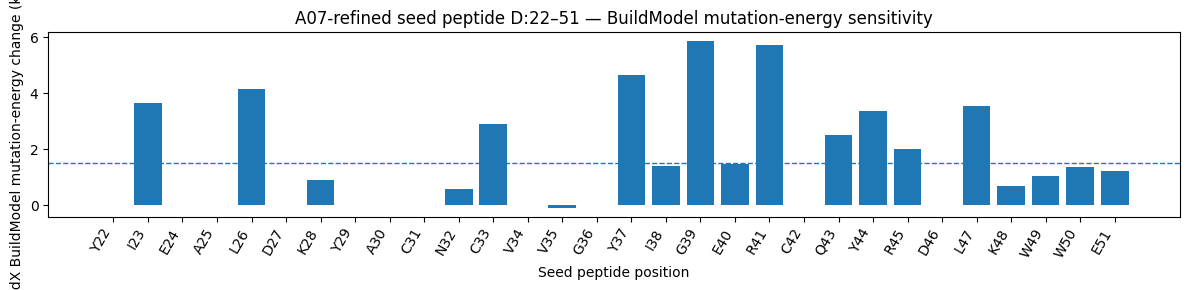

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

seed_meta = pd.read_csv("outputs/selected_energetic_seed_metadata.csv")

plt.figure(figsize=(12, 3))

x = seed_meta["pos_seed"]
y = seed_meta["ddG_kcal_mol"].fillna(0)

plt.bar(x, y)
plt.axhline(1.5, linestyle="--", linewidth=1)

labels = seed_meta["aa"] + seed_meta["resseq"].astype(str)

plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("FoldX BuildModel mutation-energy change (kcal/mol)")
plt.xlabel("Seed peptide position")
plt.title(
    "A07-refined seed peptide D:22–51 — "
    "BuildModel mutation-energy sensitivity"
)

plt.tight_layout()
plt.savefig("outputs/selected_seed_foldx_hotspot_profile.png", dpi=300)
plt.show()

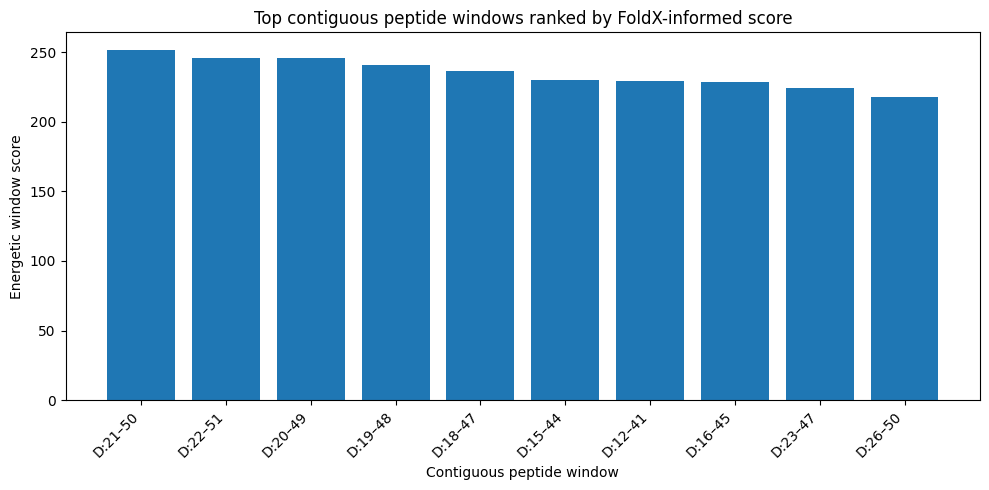

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

windows = pd.read_csv("outputs/energetic_contiguous_windows_ranked.csv")

topw = windows.head(10).copy()

topw["window"] = (
    "D:" +
    topw["start_resseq"].astype(str) +
    "–" +
    topw["end_resseq"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.bar(topw["window"], topw["energetic_window_score"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Energetic window score")
plt.xlabel("Contiguous peptide window")
plt.title("Top contiguous peptide windows ranked by FoldX-informed score")

plt.tight_layout()
plt.savefig("outputs/top_energetic_seed_windows.png", dpi=300)
plt.show()

## 10. Train the denoising model

Epoch 001 | loss = 0.6271
Epoch 002 | loss = 0.3314
Epoch 003 | loss = 0.3112
Epoch 004 | loss = 0.2925
Epoch 005 | loss = 0.2872
Epoch 006 | loss = 0.2795
Epoch 007 | loss = 0.2869
Epoch 008 | loss = 0.2806
Epoch 009 | loss = 0.2761
Epoch 010 | loss = 0.2813
Epoch 011 | loss = 0.2807
Epoch 012 | loss = 0.2808
Epoch 013 | loss = 0.2749
Epoch 014 | loss = 0.2780
Epoch 015 | loss = 0.2769
Epoch 016 | loss = 0.2776
Epoch 017 | loss = 0.2713
Epoch 018 | loss = 0.2777
Epoch 019 | loss = 0.2797
Epoch 020 | loss = 0.2783
Epoch 021 | loss = 0.2830
Epoch 022 | loss = 0.2741
Epoch 023 | loss = 0.2753
Epoch 024 | loss = 0.2768
Epoch 025 | loss = 0.2765


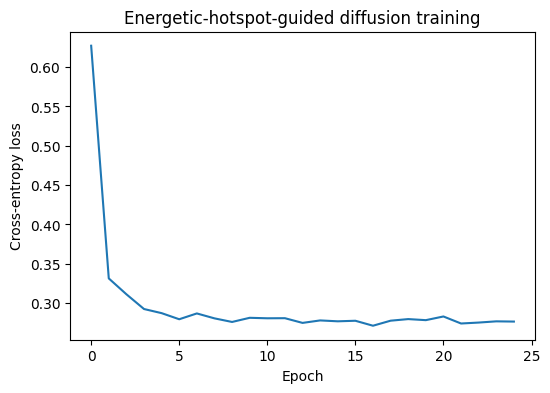

In [12]:
EPOCHS = 25

loss_history = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_losses = []

    for x0 in loader:
        x0 = x0.to(DEVICE)
        B = x0.shape[0]
        t = torch.randint(0, T, (B,), device=DEVICE)
        xt = q_sample(x0, t)

        logits = model(xt, t)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), x0.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    loss_history.append(mean_loss)
    print(f"Epoch {epoch:03d} | loss = {mean_loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Energetic-hotspot-guided diffusion training")
plt.show()


## 11. Sample peptide variants

Sampling can preserve energetic hotspots exactly.

This is the recommended mode for PEARL-compliant candidate generation.


In [13]:
@torch.no_grad()
def sample_sequences(model, n_samples=500, temperature=0.8, preserve_energetic_hotspots=True):
    model.eval()
    L = MAX_LEN
    x = torch.randint(0, VOCAB_SIZE, (n_samples, L), device=DEVICE)
    seed_tokens = encode_seq(seed_sequence).to(DEVICE)

    for step in reversed(range(T)):
        t = torch.full((n_samples,), step, device=DEVICE, dtype=torch.long)
        logits = model(x, t) / temperature
        probs = F.softmax(logits, dim=-1)
        x_new = torch.multinomial(probs.reshape(-1, VOCAB_SIZE), 1).reshape(n_samples, L)

        if preserve_energetic_hotspots:
            for pos in energetic_hotspot_positions:
                x_new[:, pos] = seed_tokens[pos]

        x = x_new

    return [decode_seq(row) for row in x]

generated_hard = sample_sequences(model, n_samples=700, temperature=0.8, preserve_energetic_hotspots=True)
generated_soft = sample_sequences(model, n_samples=300, temperature=1.0, preserve_energetic_hotspots=False)

generated = sorted(set(generated_hard + generated_soft + [seed_sequence]))

print("Unique generated sequences including seed:", len(generated))
for s in generated[:30]:
    print(s)


Unique generated sequences including seed: 194
FIDALDKYACNCVVGYIGERCQYRDLKWWE
FIDALDKYACNCVVGYIGERCQYRELKWWD
FIDALDKYACNCVVPYIGERCQYRDLKWWE
FIEAIEKYACNCVVPYIGERCQYRDLKWWE
FIEALDHFACNCIVGYIGERCQYRDLKWWE
FIEALDHYACNCVVGYIGERCQYRDLKWWE
FIEALDHYACNCVVGYIGERCQYRELKWWE
FIEALDKFACNCVVGYIGERCQYRDLKWWE
FIEALDKFACNCVVGYIGERCQYRELKWWE
FIEALDKWACNCVVPYIGERCQYRDLKWWE
FIEALDKWVCNCVVGYIGERCQYKDLKWWE
FIEALDKYACNCAVGYIGERCQYRDLKWWD
FIEALDKYACNCIVGYIGERCQYRDLKWWE
FIEALDKYACNCLVPYIGERCQYRELKWWD
FIEALDKYACNCVLGYIGERCQYRDLKWWE
FIEALDKYACNCVVGYIGDRCQYRDLKWWD
FIEALDKYACNCVVGYIGDRCQYRDLKWWE
FIEALDKYACNCVVGYIGERCNYRDLKWWE
FIEALDKYACNCVVGYIGERCQYRDLKWFE
FIEALDKYACNCVVGYIGERCQYRDLKWWD
FIEALDKYACNCVVGYIGERCQYRDLKWWE
FIEALDKYACNCVVGYIGERCQYRDLKYWE
FIEALDKYACNCVVGYIGERCQYRDLRWWE
FIEALDKYACNCVVGYIGERCQYRELKWWE
FIEALDKYACNCVVPYIGERCQYRDLKWWD
FIEALDKYACNCVVPYIGERCQYRDLKWWE
FIEALDKYACNCVVPYIGERCQYRELKWWE
FIEALDKYACQCVVGYIGERCQYRDLKWWD
FIEALDKYACTCVVGYIGDRCQYRDLKWFE
FIEALDKYACTCVVGYIGERCQYRDLKWWE


## 12. Rank candidates with energetic-hotspot-aware score

The score is still a prioritization heuristic, not a binding free-energy estimate.

It rewards:

- preservation of FoldX energetic hotspots;
- conservative physicochemical changes at interface residues;
- moderate novelty;
- reasonable sequence composition.


In [14]:
AA_GROUP = {}
for group_name, group in {
    "hydrophobic": set("AVLIMFWY"),
    "positive": set("KRH"),
    "negative": set("DE"),
    "polar": set("STNQ"),
    "special": set("GPC"),
}.items():
    for aa in group:
        AA_GROUP[aa] = group_name

def hamming_distance(a, b):
    return sum(x != y for x, y in zip(a, b))

def position_preservation(seq, seed, positions):
    if not positions:
        return 1.0
    return float(np.mean([seq[i] == seed[i] for i in positions]))

def group_similarity(seq, seed):
    return float(np.mean([AA_GROUP.get(a) == AA_GROUP.get(b) for a, b in zip(seq, seed)]))

def interface_group_similarity(seq, seed, interface_positions):
    if not interface_positions:
        return 1.0
    return float(np.mean([AA_GROUP.get(seq[i]) == AA_GROUP.get(seed[i]) for i in interface_positions]))

def composition_penalty(seq):
    cys_frac = seq.count("C") / len(seq)
    pro_frac = seq.count("P") / len(seq)
    gly_frac = seq.count("G") / len(seq)
    return (
        0.5 * max(0, cys_frac - 0.15) +
        0.3 * max(0, pro_frac - 0.25) +
        0.2 * max(0, gly_frac - 0.25)
    )

def candidate_score(seq, seed):
    energetic_hot = position_preservation(seq, seed, energetic_hotspot_positions)
    interface_exact = position_preservation(seq, seed, interface_positions)
    interface_group = interface_group_similarity(seq, seed, interface_positions)
    global_group = group_similarity(seq, seed)
    ham = hamming_distance(seq, seed) / len(seed)
    comp_pen = composition_penalty(seq)

    novelty_bonus = math.exp(-((ham - 0.25) ** 2) / (2 * 0.15 ** 2))

    score = (
        0.35 * energetic_hot +
        0.20 * interface_group +
        0.15 * interface_exact +
        0.10 * global_group +
        0.20 * novelty_bonus -
        0.10 * comp_pen
    )

    return score, energetic_hot, interface_exact, interface_group, global_group, ham, novelty_bonus, comp_pen

rows = []
for seq in generated:
    score, ehot, int_exact, int_group, grp, ham, novelty, comp_pen = candidate_score(seq, seed_sequence)
    rows.append({
        "sequence": seq,
        "is_seed": seq == seed_sequence,
        "length": len(seq),
        "score": score,
        "energetic_hotspot_preservation": ehot,
        "hotspot_preservation": ehot,  # backward-compatible alias
        "interface_exact_preservation": int_exact,
        "interface_group_similarity": int_group,
        "global_group_similarity": grp,
        "normalized_hamming": ham,
        "novelty_bonus": novelty,
        "composition_penalty": comp_pen,
        "seed_start_resseq": int(seed_df["resseq"].iloc[0]),
        "seed_end_resseq": int(seed_df["resseq"].iloc[-1]),
        "n_energetic_hotspots_in_seed": len(energetic_hotspot_positions),
        "n_interface_positions_in_seed": len(interface_positions),
    })

ranked = pd.DataFrame(rows).sort_values(["score", "is_seed"], ascending=[False, False]).reset_index(drop=True)

OUT_CANDIDATES_COMPAT = OUTPUT_DIR / "diffusion_contiguous_peptide_candidates.csv"
OUT_CANDIDATES_ENERGETIC = OUTPUT_DIR / "diffusion_energetic_peptide_candidates.csv"

ranked.to_csv(OUT_CANDIDATES_COMPAT, index=False)
ranked.to_csv(OUT_CANDIDATES_ENERGETIC, index=False)

print("Saved:", OUT_CANDIDATES_COMPAT)
print("Saved:", OUT_CANDIDATES_ENERGETIC)
display(ranked.head(40))


Saved: outputs/diffusion_contiguous_peptide_candidates.csv
Saved: outputs/diffusion_energetic_peptide_candidates.csv


,sequence,is_seed,length,score,energetic_hotspot_preservation,hotspot_preservation,interface_exact_preservation,interface_group_similarity,global_group_similarity,normalized_hamming,novelty_bonus,composition_penalty,seed_start_resseq,seed_end_resseq,n_energetic_hotspots_in_seed,n_interface_positions_in_seed
0,FIEALEKFACNCVVPYIGERCQYRDLKWWD,False,30,0.964878,1.0,1.0,0.956522,1.0,1.0,0.166667,0.856997,0.0,22,51,10,23
1,FIEALDKYACNCLVPYIGERCQYRELKWWD,False,30,0.958356,1.0,1.0,0.913043,1.0,1.0,0.166667,0.856997,0.0,22,51,10,23
2,WIEALDKWACNCMVGYIGERCQYRELKWWD,False,30,0.958356,1.0,1.0,0.913043,1.0,1.0,0.166667,0.856997,0.0,22,51,10,23
3,YIDALEKYICNCVVPYIGERCQYRELKWWE,False,30,0.958356,1.0,1.0,0.913043,1.0,1.0,0.166667,0.856997,0.0,22,51,10,23
4,FIEALDHFACNCIVGYIGERCQYRDLKWWE,False,30,0.941277,1.0,1.0,0.956522,1.0,1.0,0.133333,0.738991,0.0,22,51,10,23
5,FIDALDKYACNCVVGYIGERCQYRELKWWD,False,30,0.934755,1.0,1.0,0.913043,1.0,1.0,0.133333,0.738991,0.0,22,51,10,23
6,FIEALEKYICNCVVGYIGERCQYRDLKWWD,False,30,0.934755,1.0,1.0,0.913043,1.0,1.0,0.133333,0.738991,0.0,22,51,10,23
7,YIEALEHYACQCVVPYIGERCQYRDLKWWE,False,30,0.934755,1.0,1.0,0.913043,1.0,1.0,0.133333,0.738991,0.0,22,51,10,23
8,FIEALDKYACTCVVGYIGDRCQYRDLKWFE,False,30,0.928233,1.0,1.0,0.869565,1.0,1.0,0.133333,0.738991,0.0,22,51,10,23
9,WIDALDKYACNCAVGYIPDRCQYRDLKWWE,False,30,0.923356,0.9,0.9,0.913043,1.0,1.0,0.166667,0.856997,0.0,22,51,10,23


## 13. Mutation table versus energetic seed

In [14]:
def mutation_string(seq, seed, seed_df):
    muts = []
    for i, (a, b) in enumerate(zip(seed, seq)):
        if a != b:
            resseq = int(seed_df.loc[i, "resseq"])
            ddg = float(seed_df.loc[i, "ddG_kcal_mol"])
            is_hot = bool(seed_df.loc[i, "is_energetic_hotspot"])
            tag = "ENERGETIC_HOTSPOT" if is_hot else "non_hotspot"
            muts.append(f"{a}{resseq}{b}[ddG={ddg:.2f},{tag}]")
    return ", ".join(muts) if muts else "seed/no mutation"

top = ranked.head(25).copy()
top["mutations_vs_seed"] = top["sequence"].apply(lambda s: mutation_string(s, seed_sequence, seed_df))

display(
    top[[
        "sequence",
        "is_seed",
        "score",
        "energetic_hotspot_preservation",
        "interface_group_similarity",
        "normalized_hamming",
        "mutations_vs_seed",
    ]]
)


,sequence,is_seed,score,energetic_hotspot_preservation,interface_group_similarity,normalized_hamming,mutations_vs_seed
0,MYIDALEKFACNCMVPYIGERCQYRDLKWW,False,0.971399,1.0,1.000000,0.166667,"E24D[ddG=0.00,non_hotspot], D27E[ddG=0.00,non_..."
1,MFIDALDKFACSCVVPYIGERCQYRDLKWW,False,0.964878,1.0,1.000000,0.166667,"Y22F[ddG=0.00,non_hotspot], E24D[ddG=0.00,non_..."
2,MWIDALDKWACNCVVPYVGERCQYRDLKWW,False,0.964878,1.0,1.000000,0.166667,"Y22W[ddG=0.00,non_hotspot], E24D[ddG=0.00,non_..."
3,MYIDALDKWACNCAVPYIGERCQYRDLKWW,False,0.947798,1.0,1.000000,0.133333,"E24D[ddG=0.00,non_hotspot], Y29W[ddG=0.00,non_..."
4,MYIDALEKWACNCIVGYIGERCQYRDLKWW,False,0.947798,1.0,1.000000,0.133333,"E24D[ddG=0.00,non_hotspot], D27E[ddG=0.00,non_..."
5,MYIDALEKWACNCVVPYIGERCQYRDLKWW,False,0.947798,1.0,1.000000,0.133333,"E24D[ddG=0.00,non_hotspot], D27E[ddG=0.00,non_..."
6,MYIDALEKYACNCIVPYIGERCQYRDLKWW,False,0.947798,1.0,1.000000,0.133333,"E24D[ddG=0.00,non_hotspot], D27E[ddG=0.00,non_..."
7,MYIEALEKYAATCIVPYIGERCQYRDLKWW,False,0.946327,1.0,0.956522,0.166667,"D27E[ddG=0.00,non_hotspot], C31A[ddG=-0.00,non..."
8,MFIDALEKYACSCVVGYIGERCQYRDLKWW,False,0.941277,1.0,1.000000,0.133333,"Y22F[ddG=0.00,non_hotspot], E24D[ddG=0.00,non_..."
9,MWIEALEKFACNCVLGYIGERCQYRDLKWW,False,0.941277,1.0,1.000000,0.133333,"Y22W[ddG=0.00,non_hotspot], D27E[ddG=0.00,non_..."


## 14. Export FASTA for downstream validation

This file can be used later for ESMFold/ColabFold-style structure prediction or docking preparation.


In [15]:
TOP_N = 10

top_export = pd.concat([
    ranked[ranked["is_seed"] == True].head(1),
    ranked[ranked["is_seed"] == False].head(TOP_N)
], ignore_index=True)

fasta_lines = []
for i, row in top_export.iterrows():
    if bool(row["is_seed"]):
        label = "seed_reference"
    else:
        label = f"candidate_{i:02d}"
    header = f">{label}|score={row['score']:.4f}|energetic_hotspot_preservation={row['energetic_hotspot_preservation']:.3f}"
    fasta_lines.append(header)
    fasta_lines.append(str(row["sequence"]))

OUT_FASTA = OUTPUT_DIR / "top_diffusion_energetic_peptides.fasta"
OUT_FASTA.write_text(NL.join(fasta_lines) + NL, encoding="utf-8")

print("Saved:", OUT_FASTA)
print(OUT_FASTA.read_text(encoding="utf-8"))


Saved: outputs/top_diffusion_energetic_peptides.fasta
>seed_reference|score=0.8499|energetic_hotspot_preservation=1.000
MYIEALDKYACNCVVGYIGERCQYRDLKWW
>candidate_01|score=0.9714|energetic_hotspot_preservation=1.000
MYIDALEKFACNCMVPYIGERCQYRDLKWW
>candidate_02|score=0.9649|energetic_hotspot_preservation=1.000
MFIDALDKFACSCVVPYIGERCQYRDLKWW
>candidate_03|score=0.9649|energetic_hotspot_preservation=1.000
MWIDALDKWACNCVVPYVGERCQYRDLKWW
>candidate_04|score=0.9478|energetic_hotspot_preservation=1.000
MYIDALDKWACNCAVPYIGERCQYRDLKWW
>candidate_05|score=0.9478|energetic_hotspot_preservation=1.000
MYIDALEKWACNCIVGYIGERCQYRDLKWW
>candidate_06|score=0.9478|energetic_hotspot_preservation=1.000
MYIDALEKWACNCVVPYIGERCQYRDLKWW
>candidate_07|score=0.9478|energetic_hotspot_preservation=1.000
MYIDALEKYACNCIVPYIGERCQYRDLKWW
>candidate_08|score=0.9463|energetic_hotspot_preservation=1.000
MYIEALEKYAATCIVPYIGERCQYRDLKWW
>candidate_09|score=0.9413|energetic_hotspot_preservation=1.000
MFIDALEKYACSCVVGYIGERCQYR

Candidate file used: outputs/diffusion_energetic_peptide_candidates.csv
Columns: ['sequence', 'is_seed', 'length', 'score', 'energetic_hotspot_preservation', 'hotspot_preservation', 'interface_exact_preservation', 'interface_group_similarity', 'global_group_similarity', 'normalized_hamming', 'novelty_bonus', 'composition_penalty', 'seed_start_resseq', 'seed_end_resseq', 'n_energetic_hotspots_in_seed', 'n_interface_positions_in_seed']
Seed sequence:          YIEALDKYACNCVVGYIGERCQYRDLKWWE
Top candidate sequence: FIEALEKFACNCVVPYIGERCQYRDLKWWD
Top candidate score:    0.9649


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
seed,0.066667,0.1,0.066667,0.1,0.000000,0.066667,0.0,0.066667,0.066667,0.066667,0.0,0.033333,0.000000,0.033333,0.066667,0.0,0.0,0.066667,0.066667,0.133333
top_candidate,0.066667,0.1,0.066667,0.1,0.066667,0.033333,0.0,0.066667,0.066667,0.066667,0.0,0.033333,0.033333,0.033333,0.066667,0.0,0.0,0.066667,0.066667,0.066667


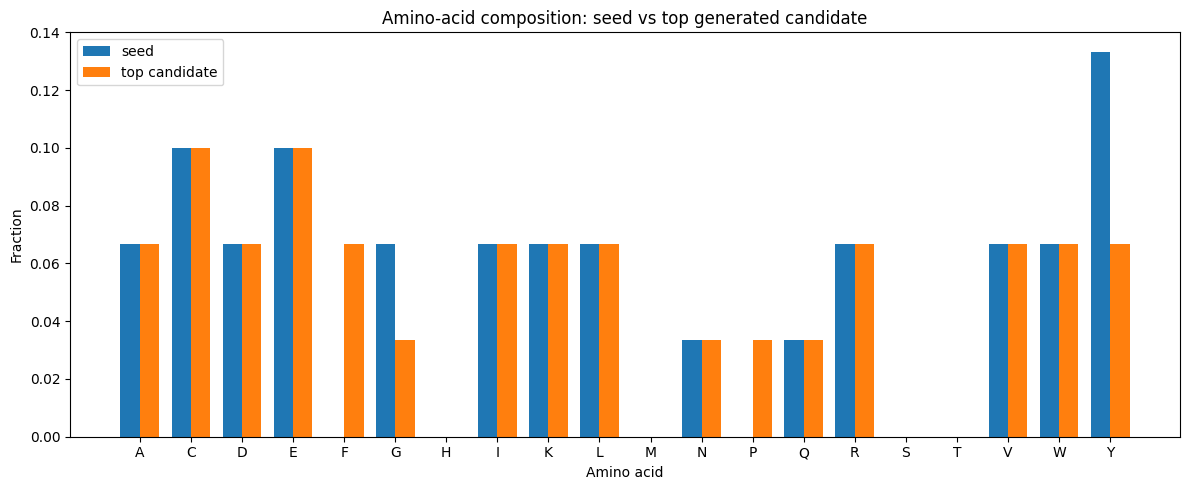

Saved table: outputs/seed_vs_top_candidate_amino_acid_composition.csv
Saved plot:  outputs/seed_vs_top_candidate_amino_acid_composition.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# AMINO-ACID COMPOSITION:
# SEED VS TOP GENERATED CANDIDATE
# ============================================================

AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")

# ------------------------------------------------------------
# 1. CARICAMENTO DEI CANDIDATI
# ------------------------------------------------------------

candidate_file = (
    OUTPUT_DIR /
    "diffusion_energetic_peptide_candidates.csv"
)

if not candidate_file.exists():
    candidate_file = (
        OUTPUT_DIR /
        "diffusion_contiguous_peptide_candidates.csv"
    )

if not candidate_file.exists():
    raise FileNotFoundError(
        "Non è stato trovato alcun file CSV con i candidati."
    )

candidate_table = pd.read_csv(candidate_file)

print(f"Candidate file used: {candidate_file}")
print("Columns:", candidate_table.columns.tolist())

required_columns = {"sequence", "score"}

missing_columns = required_columns - set(candidate_table.columns)

if missing_columns:
    raise KeyError(
        f"Colonne mancanti nel file candidati: {missing_columns}"
    )

# Pulizia delle sequenze
candidate_table["sequence"] = (
    candidate_table["sequence"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# 2. RECUPERO DEL SEED
# ------------------------------------------------------------

seed_sequence = None

if "is_seed" in candidate_table.columns:

    # Gestione robusta nel caso is_seed sia booleano o stringa
    is_seed_mask = (
        candidate_table["is_seed"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

    seed_rows = candidate_table[is_seed_mask]

    if not seed_rows.empty:
        seed_sequence = seed_rows.iloc[0]["sequence"]

# Fallback coerente con la selezione A07.
# Se seed_sequence non è disponibile, ricostruisce il seed
# dalla finestra D:22-51 selezionata in precedenza.

if (
    seed_sequence is None
    or pd.isna(seed_sequence)
    or str(seed_sequence).strip().upper() in {"", "NONE", "NAN"}
):
    if "seed_df" in globals() and not seed_df.empty:
        seed_sequence = "".join(seed_df["aa"].astype(str).tolist())
    else:
        raise RuntimeError(
            "seed_sequence is not available and seed_df is missing. "
            "Run the A07-refined seed-selection cell first."
        )

seed_sequence = str(seed_sequence).strip().upper()

# Safety checks: the updated PEARL workflow must use the
# A07-refined D:22-51 seed.
assert len(seed_sequence) == 30, (
    f"Expected a 30-residue seed, found {len(seed_sequence)}."
)

assert seed_sequence == "YIEALDKYACNCVVGYIGERCQYRDLKWWE", (
    "Unexpected seed sequence. Expected the A07-refined D:22-51 seed, "
    f"but obtained: {seed_sequence}"
)

# ------------------------------------------------------------
# 3. MIGLIOR CANDIDATO NON-SEED
# ------------------------------------------------------------

non_seed_candidates = candidate_table[
    candidate_table["sequence"] != seed_sequence
].copy()

if non_seed_candidates.empty:
    raise ValueError(
        "Non sono presenti candidati diversi dal seed."
    )

top_candidate_row = non_seed_candidates.sort_values(
    "score",
    ascending=False
).iloc[0]

top_candidate_sequence = str(
    top_candidate_row["sequence"]
).strip().upper()

print(f"Seed sequence:          {seed_sequence}")
print(f"Top candidate sequence: {top_candidate_sequence}")
print(f"Top candidate score:    {top_candidate_row['score']:.4f}")

# ------------------------------------------------------------
# 4. VALIDAZIONE DELLE SEQUENZE
# ------------------------------------------------------------

def validate_sequence(sequence, name):
    invalid_symbols = set(sequence) - set(AA_ORDER)

    if invalid_symbols:
        raise ValueError(
            f"Simboli non validi nella sequenza {name}: "
            f"{invalid_symbols}"
        )

    if len(sequence) == 0:
        raise ValueError(
            f"La sequenza {name} è vuota."
        )

validate_sequence(seed_sequence, "seed")
validate_sequence(top_candidate_sequence, "top candidate")

# ------------------------------------------------------------
# 5. CALCOLO DELLA COMPOSIZIONE
# ------------------------------------------------------------

def amino_acid_composition(sequence):
    return {
        aa: sequence.count(aa) / len(sequence)
        for aa in AA_ORDER
    }

seed_composition = amino_acid_composition(
    seed_sequence
)

top_composition = amino_acid_composition(
    top_candidate_sequence
)

composition_df = pd.DataFrame(
    [
        seed_composition,
        top_composition
    ],
    index=["seed", "top_candidate"]
)

display(composition_df)

# ------------------------------------------------------------
# 6. SALVATAGGIO DELLA TABELLA
# ------------------------------------------------------------

composition_csv_path = (
    OUTPUT_DIR /
    "seed_vs_top_candidate_amino_acid_composition.csv"
)

composition_df.to_csv(composition_csv_path)

# ------------------------------------------------------------
# 7. GRAFICO
# ------------------------------------------------------------

x = np.arange(len(AA_ORDER))
bar_width = 0.38

plt.figure(figsize=(12, 5))

plt.bar(
    x - bar_width / 2,
    composition_df.loc["seed", AA_ORDER],
    width=bar_width,
    label="seed"
)

plt.bar(
    x + bar_width / 2,
    composition_df.loc["top_candidate", AA_ORDER],
    width=bar_width,
    label="top candidate"
)

plt.xticks(x, AA_ORDER)
plt.xlabel("Amino acid")
plt.ylabel("Fraction")
plt.title(
    "Amino-acid composition: "
    "seed vs top generated candidate"
)

plt.legend()
plt.tight_layout()

composition_plot_path = (
    OUTPUT_DIR /
    "seed_vs_top_candidate_amino_acid_composition.png"
)

plt.savefig(
    composition_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved table: {composition_csv_path}")
print(f"Saved plot:  {composition_plot_path}")

## 15. Interpretation for the report

Suggested wording:

> A FoldX alanine-scanning table was used to identify energetic hotspots according to the ΔΔG > 1.5 kcal/mol criterion. These FoldX-derived energetic residues were mapped to the peptide design problem either directly, when the peptide residue itself was an energetic hotspot, or indirectly, when a peptide residue contacted a receptor energetic hotspot. A contiguous seed peptide window was selected to cover these energetic design anchors. A categorical denoising diffusion model was trained on local conservative variants of this seed and sampled while preserving energetic-anchor positions. Generated sequences were ranked as pre-validation candidates, not as confirmed binders.

Important distinction:

- `is_energetic_hotspot` = direct FoldX ΔΔG-based hotspot on the peptide residue.
- `contacts_receptor_energetic_hotspot` = peptide residue contacting a receptor energetic hotspot.
- `is_energetic_design_anchor` = either of the above.
- `graph_proxy_score` = auxiliary topological interpretation.
